In [52]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_node_cleaner_swell_GP_train_single_more_layers_lib_3 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_node_cleaner_swell_GP_train_single_more_layers_lib_3 import *
import_reload()

In [53]:
RUN_ID = 'u_per_min10_2'
DT = 1
Q0 = 17921.57581 
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  .03,
    's':  0.1
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

In [54]:
model_name = 'ecm_node_0507_1021_swelling_pulse_dynamic_netR0_R0c_R1c_C1c_35.59min_16h_0_200eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)
display(data.head())

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'true', 'R1_min': 0.005, 'R1_max': 0.2, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 50000.0, 'R0_constrained': 'true', 'R0_min': 0.008, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.0, 'k_max': 1.0, 's_constrained': 'true', 's_min': 0.0, 's_max': 1.0, 'style': 'dynamic'}
Using I_ref = 24.791513200977658 and 'u_ref' = -0.0862395023328149 for model parameters
k constrained to [0.0, 1.0] GN/1e-5m
s constrained to [0.0, 1.0] 1e-5 m
R1 constrained to [0.005, 0.2] Ohm
C1 constrained to [500.0, 50000.0] F
R0 constrained to [0.008, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.009786,7851.415039,0.008,0.03191,0.038798
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.009785,7851.419434,0.008,0.03191,0.038809
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.009785,7851.423828,0.008,0.03191,0.038819
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.009784,7851.428223,0.008,0.03191,0.038829
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.009784,7851.432617,0.008,0.03191,0.038839


# Importing data

In [55]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 100


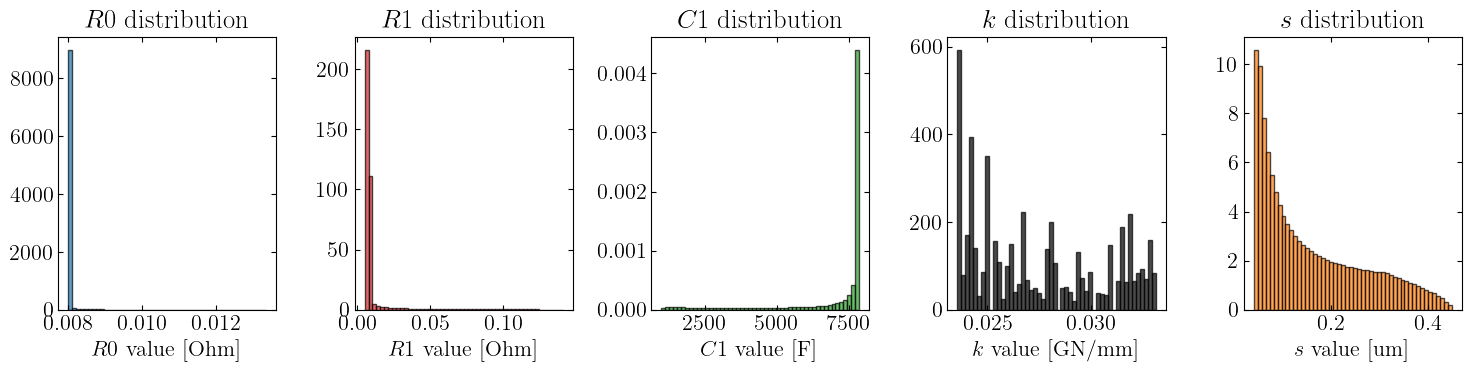

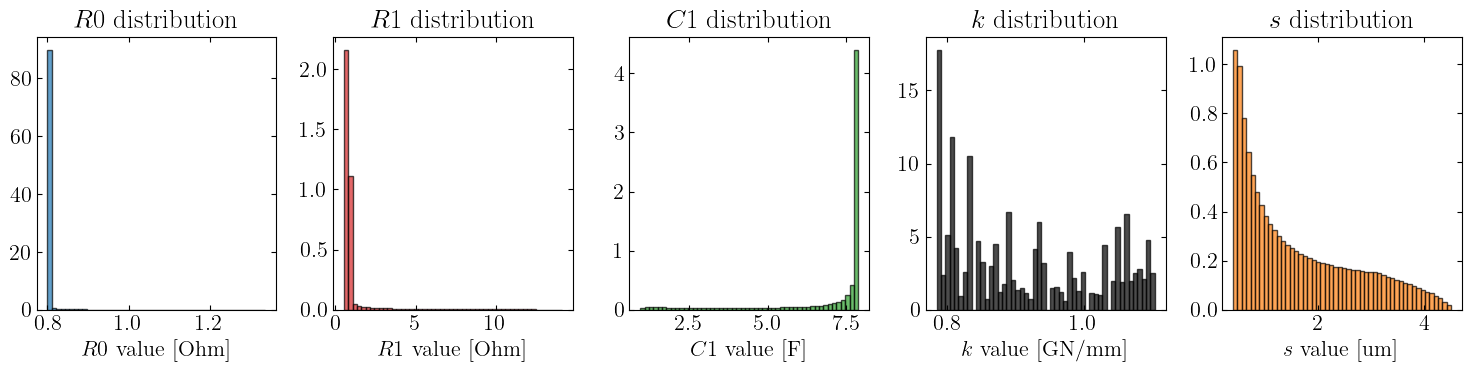

In [56]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [57]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 1e6:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['s'].values  / REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds]

In [58]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 1th data point for symbolic regression, total points: 155300
Using every 1th data point for symbolic regression, total points: 12604


In [59]:
# def print_models(df_model):
#     for i in range(len(df_model)):
#         print(f"Model {i}: Complexity={df_model['complexity'][i]}, Loss={df_model['loss'][i]}")
#         print(f"Equation: {df_model['equation'][i]}\n")

# def print_best_model(model, model_index = None):
#     best = model.get_best()
#     display(Math(f'\\LARGE {model.latex(model_index)}'))
#     display(Math(r'\LARGE $x_0 = \mathrm{{c}}$-rate$'))
#     display(Math(r'\LARGE $x_1 = \Delta u / L_{{tot}}$'))
#     display(Math(r'\LARGE $x_2 = \mathrm{SOC}$'))
#     print(f'Best model in symbolic form: {model.sympy()}\nLoss: {best["loss"]}\nBest model complexity: {best["complexity"]}')

In [60]:
# # Parity plot
# def pareto_plot(model):
#     df_model = model.equations_
#     best = model.get_best()
#     plt.grid(True, which="both", ls="-", linewidth=0.5)
#     plt.plot(df_model['complexity'], df_model['loss'], marker='o', linestyle='-', color=colors[0], label='Models')
#     plt.plot(best['complexity'], best['loss'],'o', color=colors[1], label='Best Model')
#     plt.xlabel('Complexity')
#     plt.ylabel('Loss')
#     plt.yscale('log')
#     plt.title('Model Complexity vs Loss')
#     plt.legend()
#     plt.show()

# def parity_plot(element,model, X_test = X_test, Yk_test = Yk_test, YC_test = YC_test, Y_R1_test = YR1_test):
#     if element == 'R1':
#         Y_test = YR1_test
#     elif element == 'k':
#         Y_test = Yk_test
#     elif element == 'C_1':
#         Y_test = YC_test

#     Y_pred = model.predict(X_test)
#     plt.scatter(Y_test, Y_pred, color=colors[0],alpha = 0.5)
#     plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', lw=2)
#     plt.xlabel(f'Actual ${element}$ [a.u.]')
#     plt.ylabel(f'Predicted ${element}$ [a.u.]')
#     plt.show()

# def save_expressions(df_model, element):
#     df_model.to_csv(f'sr_models/model_{element}.csv', index=False)

# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

In [ ]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its  = 10)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


# $R_1 = f_R(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=2.8208456
Equation: 1.1610134

Model 1: Complexity=3, Loss=1.4464854
Equation: 0.3729334 / x2

Model 2: Complexity=4, Loss=1.4307181
Equation: 0.3688745 / tanh(x2)

Model 3: Complexity=5, Loss=1.1889514
Equation: (0.3729334 / x2) ^ x0

Model 4: Complexity=7, Loss=0.96974415
Equation: cosh(log(x2 + x2)) ^ x0

Model 5: Complexity=8, Loss=0.92823356
Equation: cosh(log(tanh(x2) + x2)) ^ x0

Model 6: Complexity=9, Loss=0.6939307
Equation: cosh(log((0.6990964 * x2) + x2)) ^ x0

Model 7: Complexity=11, Loss=0.4942909
Equation: cosh((1.2831657 - x2) * log(x2 + x2)) ^ x0

Model 8: Complexity=14, Loss=0.48874548
Equation: cosh(((cos(x2) - x2) + 0.27871296) * log(x2 + x2)) ^ x0

Model 9: Complexity=15, Loss=0.43113434
Equation: cosh((x2 / x1) + ((log(x2) + (1.1439056 - x2)) * (1.4848768 ^ x0)))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: cosh(1.4848768**x0*(-x2 + log(x2) + 1.1439056) + x2/x1)
Loss: 0.43113434
Best model complexity: 15


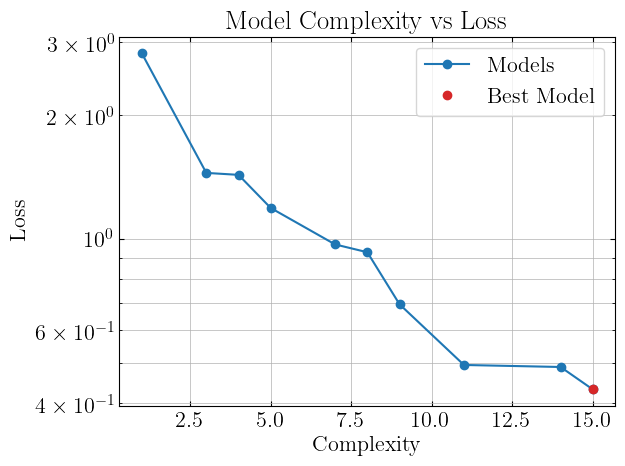

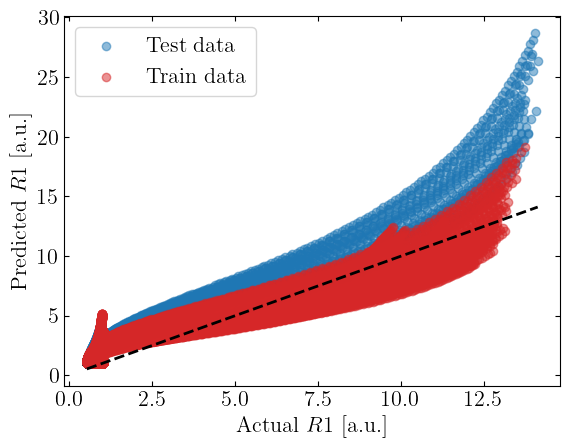

In [66]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = 10)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=3.1785343
Equation: 6.9106746

Model 1: Complexity=3, Loss=2.5434556
Equation: x2 + 6.373128

Model 2: Complexity=4, Loss=1.4490283
Equation: log(x2) + 7.718724

Model 3: Complexity=5, Loss=0.6390753
Equation: log(square(x2)) - -8.528556

Model 4: Complexity=7, Loss=0.37319478
Equation: 8.883054 - square(x2 - log(x2))

Model 5: Complexity=8, Loss=0.32694426
Equation: 8.798969 - (square(log(x2)) + tanh(x0))

Model 6: Complexity=10, Loss=0.09597903
Equation: cosh(exp(tanh(cube(x2 + tan(x2 - -0.48548725)))))

Model 7: Complexity=11, Loss=0.07637864
Equation: sinh(exp(tanh(square(square(tan(x2 - -0.5893081))))) + 0.030463357)

Model 8: Complexity=12, Loss=0.07382295
Equation: cosh(exp(tanh(cube(x2 + tan(x2 - -0.4747944)))) + 0.023039758)

Model 9: Complexity=13, Loss=0.06952393
Equation: cosh(exp(tanh(cube(((x2 + x2) + x2) - -0.40276963))) + 0.021440966)

Model 10: Complexity=14, Loss=0.056041777
Equation: sinh(exp(tanh(square(square((sqrt(sqrt(x2)) - -0.1388341

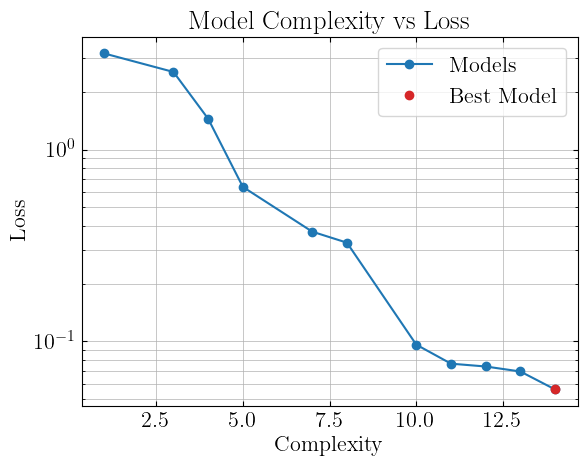

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: sinh(exp(tanh((x2**(1/4) + x2 + 0.13883418)**4))) + 0.2395414
Loss: 0.056041777
Best model complexity: 14


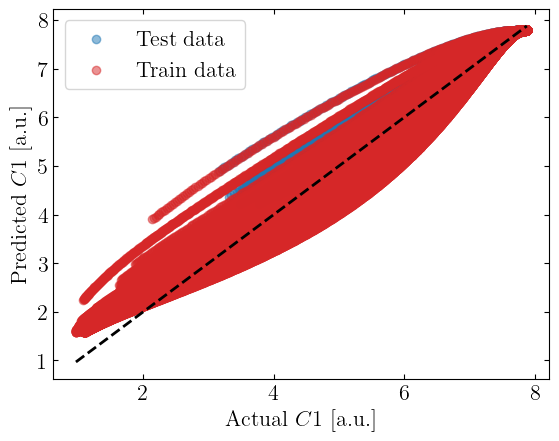

In [67]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = 10)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.011169893
Equation: 0.912458

Model 1: Complexity=4, Loss=0.0033799962
Equation: tanh(1.0324014 ^ x1)

Model 2: Complexity=5, Loss=0.0011463646
Equation: (x1 * 0.011646202) + 0.74293804

Model 3: Complexity=7, Loss=0.0011463643
Equation: ((x1 * 0.006552629) + 0.41801083) * 1.7773201

Model 4: Complexity=11, Loss=0.00081666146
Equation: sqrt(sinh(cosh(sqrt((1.0306189 ^ x1) * 0.5200282)))) + -0.5112845

Model 5: Complexity=12, Loss=0.0006247262
Equation: sqrt(square(tanh(cosh(cube(sqrt(sqrt(x1)) + -1.1058884))) * 1.0718966))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 1.0718966*sqrt(tanh(cosh((x1**(1/4) - 1.1058884)**3))**2)
Loss: 0.0006247262
Best model complexity: 12


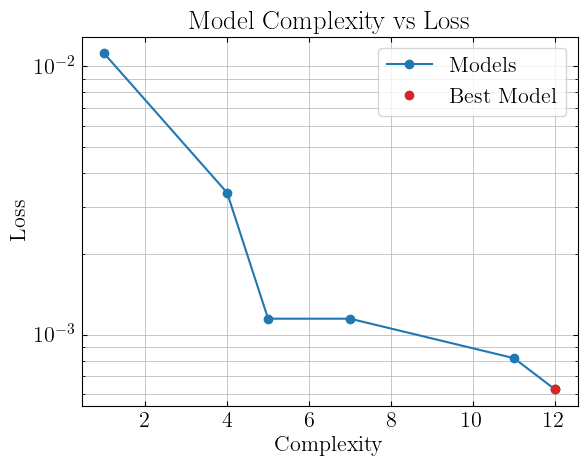

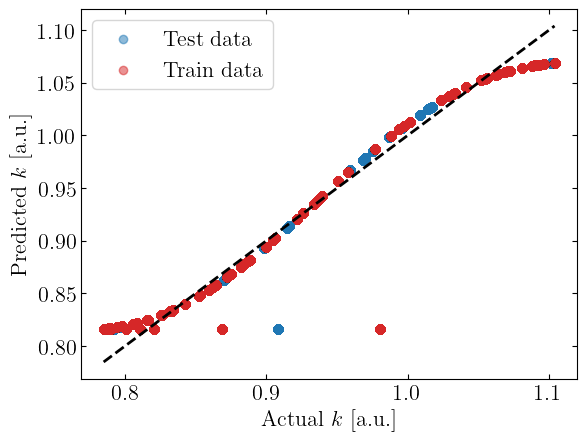

In [68]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its  = 10)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $s = f_s(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.2089075
Equation: 1.6044543

Model 1: Complexity=3, Loss=0.7160998
Equation: 2.1410866 - x2

Model 2: Complexity=4, Loss=0.0121514695
Equation: cube(1.6494013 - x2)

Model 3: Complexity=8, Loss=0.00322697
Equation: (square(x2 - 0.94839257) / 0.21207643) + 0.46448094

Model 4: Complexity=10, Loss=0.0032131888
Equation: (square((x2 + 0.009667251) - 0.9580607) + 0.09787849) / 0.21162997



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: ((x2 - 1*0.9580607 + 0.009667251)**2 + 0.09787849)/0.21162997
Loss: 0.0032131888
Best model complexity: 10


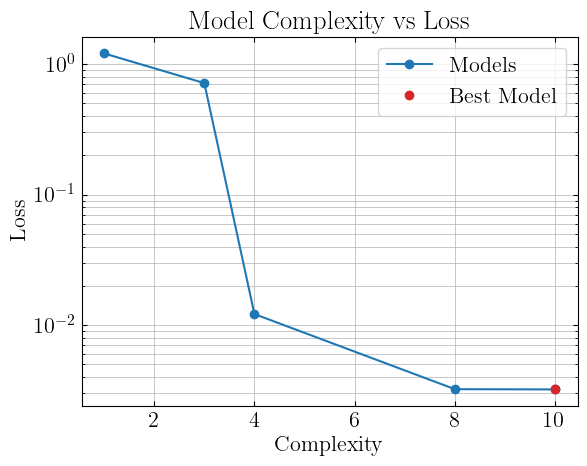

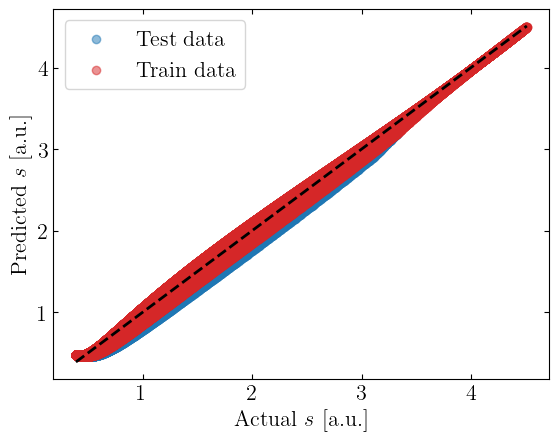

In [71]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(X_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its  = 10)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

In [72]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

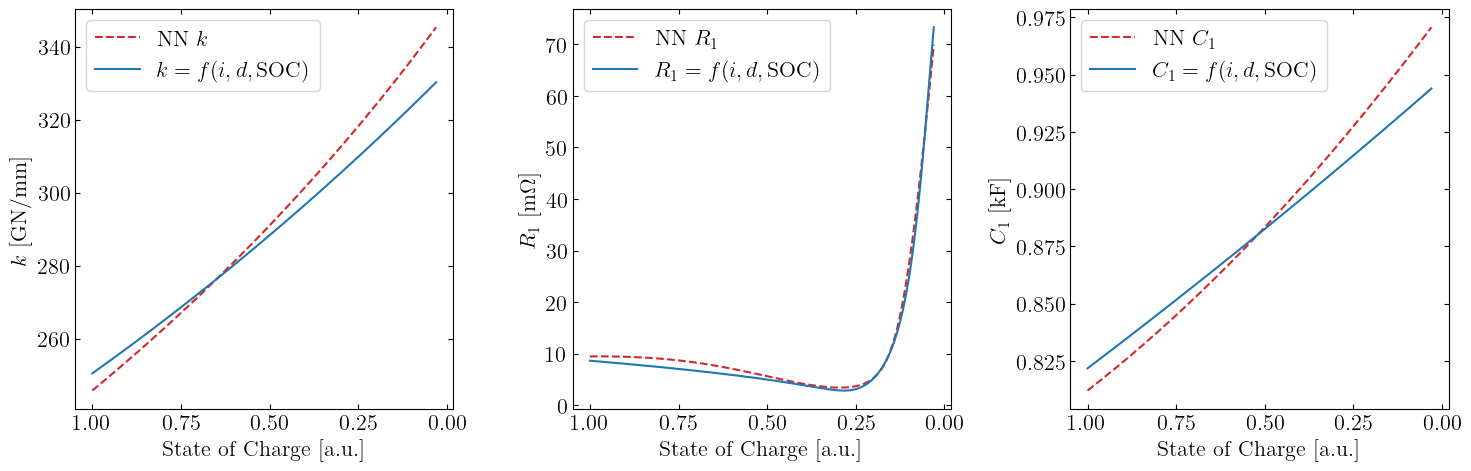

In [ ]:
def plot_trajs_SOC(data = data, ind = 0, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    tr = prepare_data(data, index = ind, test=test)
    X = tr[['C', 'u_per', 'soc']].values
    Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    f,ax = plt.subplots(1,3, figsize=(15,5))
    ax[0].plot(tr['soc'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    ax[0].plot(tr['soc'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[1].plot(tr['soc'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    ax[1].plot(tr['soc'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    ax[2].plot(tr['soc'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    ax[2].plot(tr['soc'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    for a in ax:
        a.set_xlabel('State of Charge [a.u.]')
        a.legend()
        a.invert_xaxis()
    ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 

    plt.tight_layout()
    plt.savefig('symbolic_traj_test.pdf')

plot_trajs_SOC(test = False, ind = 4)

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required.

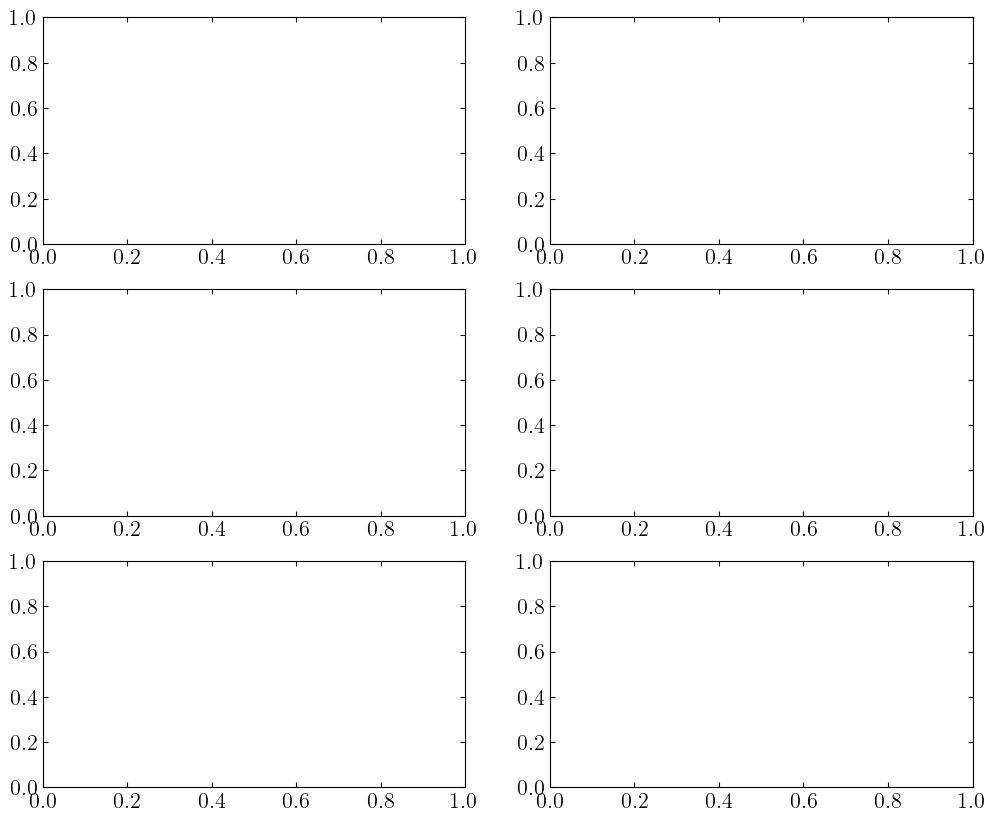

In [ ]:
def plot_trajs_C_d(data = data, modelR = model_R1, modelC = model_C1,model_0 = model_k, test = False):
    f,axs = plt.subplots(3,2, figsize=(12,10))
    
    train_index = int(0.8 * N_TRAJS )
    test_index = int(N_TRAJS - train_index)
    if test:
        ind = test_index
    else:
        ind = train_index
    i=0
    k_pred = np.zeros((ind,3)); R1_pred = np.zeros((ind,3)); C1_pred = np.zeros((ind,3))
    k_true = np.zeros((ind,3)); R1_true = np.zeros((ind,3)); C1_true = np.zeros((ind,3))
    X_vals = np.zeros((ind,2))    
    while i < ind:
        tr = prepare_data(data, index = i, test=test)
        X = tr[['C', 'u_per', 'soc']].values
        Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
        YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
        YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
        
        k_pred[i,0] = Yk_pred.mean(); R1_pred[i,0] = YR1_pred.mean(); C1_pred[i,0] = YC_pred.mean()
        k_pred[i,1] = Yk_pred.min(); R1_pred[i,1] = YR1_pred.min(); C1_pred[i,1] = YC_pred.min()
        k_pred[i,2] = Yk_pred.max(); R1_pred[i,2] = YR1_pred.max(); C1_pred[i,2] = YC_pred.max()

        k_true[i,0] = tr['k'].mean() * 100; R1_true[i,0] = tr['R1'].mean() * 1000; C1_true[i,0] = tr['C1'].mean() / 1000
        k_true[i,1] = tr['k'].min() * 100; R1_true[i,1] = tr['R1'].min() * 1000; C1_true[i,1] = tr['C1'].min() / 1000
        k_true[i,2] = tr['k'].max() * 100; R1_true[i,2] = tr['R1'].max() * 1000; C1_true[i,2] = tr['C1'].max() / 1000
        X_vals[i,0] = X[0,0]; X_vals[i,1] = X[0,1]
        i += 1

    for j in range(len(axs[0,:])):
        ax = axs[:,j]
        x = X_vals[:,j]
        ax[0].scatter(x, k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[0].scatter(x, k_true[:,0], label=r'NN $k$',  color=colors[1], alpha=0.7)
        #ax[0].plot(x, k_true[:,1] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].plot(x, k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.7, linestyle='--')
        #ax[0].fill_between(x, k_true[:,1] * X_vals[:,1], k_true[:,2] * X_vals[:,1], color=colors[1], alpha=0.2, label='NN range')
        #ax[1].fill_between(x, R1_true[:,1] , R1_true[:,2], color=colors[1], alpha=0.2, label='NN range')
        #ax[2].fill_between(x, C1_true[:,1], C1_true[:,2], color=colors[1], alpha=0.2, label='NN range')

        ax[1].scatter(x, R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
        ax[1].scatter(x, R1_true[:,0], label=r'NN $R_1$',  color=colors[1], alpha=0.7)
        ax[2].scatter(x, C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
        ax[2].scatter(x, C1_true[:,0], label=r'NN $C_1$', color=colors[1], alpha=0.7)
        ax[0].set_ylabel(r'$k$ [GN/mm]');ax[2].set_ylabel(r'$C_1$ [kF]');ax[1].set_ylabel(r'$R_1$ [m$\Omega$]') 
        
        ax[0].legend(); ax[1].legend(); ax[2].legend()
    for a in axs[:,0]:
        a.set_xlabel('C-rate [a.u.]')
    for a in axs[:,1]:
        a.set_xlabel(r'$\Delta u / L_{tot}$ [a.u.]')
    # for tr in test_trajs:
    #     X = tr[['C', 'u_per', 'soc']].values
    #     Yk_pred =  model_0.predict(X) * REF_VALUES['k'] * 100
    #     YR1_pred = modelR.predict(X) * REF_VALUES['R1'] * 1000
    #     YC_pred =  modelC.predict(X) * REF_VALUES['C1'] / 1000
    #     f,ax = plt.subplots(1,3, figsize=(15,5))
    #     ax[0].plot(tr['C'], tr['k'] * 100, label=r'NN $k$',  color=colors[1], linestyle='--')
    #     ax[0].plot(tr['C'], Yk_pred, label=r'$k = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[1].plot(tr['C'], tr['R1'] * 1000, label=r'NN $R_1$',  color=colors[1], linestyle='--')
    #     ax[1].plot(tr['C'], YR1_pred, label=r'$R_1 = f(i,d,\mathrm{SOC})$',color=colors[0])
    #     ax[2].plot(tr['C'], tr['C1'] / 1000, label=r'NN $C_1$', color=colors[1], linestyle='--')
    #     ax[2].plot(tr['C'], YC_pred, label=r'$C_1 = f(i,d,\mathrm{SOC})$', color=colors[0])
    #     for a in ax:
    #         a.set_xlabel('C-rate [a.u.]')
    #         a.legend()
    #         a.invert_xaxis()
        
            
         
    plt.tight_layout()

    plt.show()
    f,ax = plt.subplots(1,3, figsize=(15,4))
    ax[0].scatter(X_vals[:,0],X_vals[:,1],c= k_pred[:,0], label=r'$k = f(i,d,\mathrm{SOC})$',cmap = 'Blues')
    ax[0].set_xlabel('C-rate [a.u.]')
    ax[0].set_ylabel(r'$k$ [GN/mm]')
    ax[0].legend()
    ax[1].scatter(X_vals[:,0],X_vals[:,1],c= R1_pred[:,0], label=r'$R_1 = f(i,d,\mathrm{SOC})$',cmap = 'Greens')
    ax[1].set_xlabel('C-rate [a.u.]')
    ax[1].set_ylabel(r'$R_1$ [m$\Omega$]')
    ax[1].legend()
    ax[2].scatter(X_vals[:,0],X_vals[:,1],c= C1_pred[:,0], label=r'$C_1 = f(i,d,\mathrm{SOC})$',cmap = 'Oranges')
    ax[2].set_xlabel('C-rate [a.u.]')
    ax[2].set_ylabel(r'$C_1$ [kF]')
    ax[2].legend()
    plt.tight_layout()

plot_trajs_C_d(test = False)

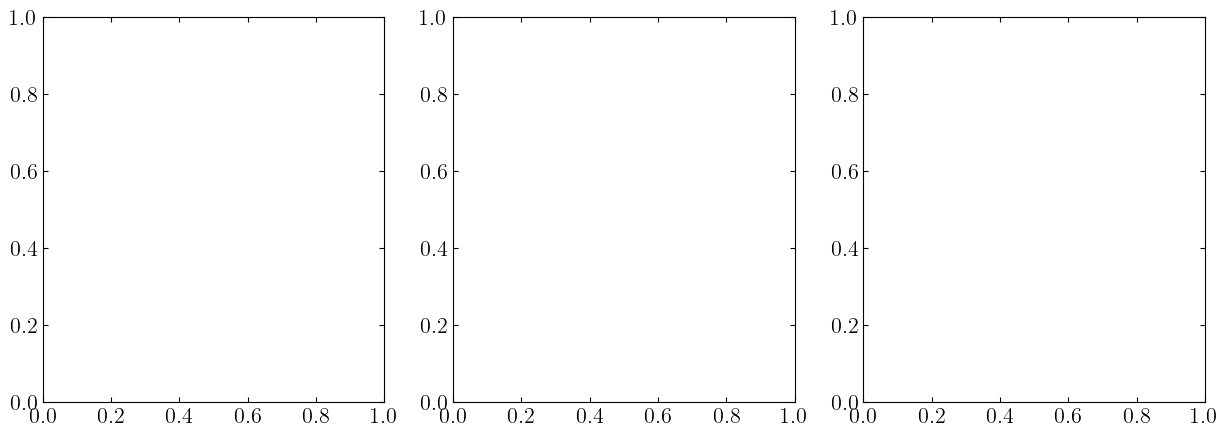

In [ ]:
f,ax = plt.subplots(1,3, figsize=(15,5))

In [ ]:
if SAVE:
    save_expressions(df_model_k,  f'k_{RUN_ID}')
    save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    save_expressions(df_model_R1, f'R1_{RUN_ID}')
    save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    save_expressions(df_model_C1, f'C1_{RUN_ID}')
    save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')